<a href="https://colab.research.google.com/github/trashpanda900/Data-Science/blob/main/TeddMcbr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymc-bart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.2 MB/s eta 0:00:00


In [ ]:
import pymc_bart as pmb
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

For my project, I initially wanted to predict percentage with education less than a highsschool diploma using purely enviormental factors. After doing this, I decided that this was unrealisitic and I should use the economic data that is available in this dataset as well.

In [ ]:
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv"
counties = pd.read_csv(url)
counties = counties.query('`area (km^2)` < 200000')
print(list(counties))

['name', 'fips', 'state', 'land_area (km^2)', 'area (km^2)', 'longitude (deg)', 'latitude (deg)', 'noaa/prcp', 'noaa/snow', 'noaa/temp', 'noaa/altitude', 'noaa/temp-jan', 'noaa/temp-apr', 'noaa/temp-jul', 'noaa/temp-oct', 'zip-codes', 'race/non_hispanic_white_alone_male', 'race/non_hispanic_white_alone_female', 'race/black_alone_male', 'race/black_alone_female', 'race/asian_alone_male', 'race/asian_alone_female', 'race/hispanic_male', 'race/hispanic_female', 'age/0-4', 'age/5-9', 'age/10-14', 'age/15-19', 'age/20-24', 'age/25-29', 'age/30-34', 'age/35-39', 'age/40-44', 'age/45-49', 'age/50-54', 'age/55-59', 'age/60-64', 'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+', 'male', 'female', 'population/2010', 'population/2011', 'population/2012', 'population/2013', 'population/2014', 'population/2015', 'population/2016', 'population/2017', 'population/2018', 'population/2019', 'deaths/suicides', 'deaths/firearm suicides', 'deaths/homicides', 'deaths/vehicle', 'bls/2004/labor_f

In [ ]:
counties=counties.loc[:,["name","area (km^2)","longitude (deg)","latitude (deg)","noaa/prcp","noaa/snow","noaa/temp","edu/less-than-high-school"]]
counties

,name,area (km^2),longitude (deg),latitude (deg),noaa/prcp,noaa/snow,noaa/temp,edu/less-than-high-school
0,cuming county,1488.343176,-96.787366,41.916346,30.5,28.2,48.8,11.6
1,lancaster county,2192.120047,-96.688211,40.784132,31.0,25.3,51.0,6.3
2,nuckolls county,1491.363670,-98.047277,40.176383,27.7,22.2,51.5,8.1
3,keith county,2874.204062,-101.657059,41.198294,20.0,25.0,50.0,8.5
4,phelps county,1399.695104,-99.414593,40.513105,25.5,26.7,50.3,6.7
...,...,...,...,...,...,...,...,...
3137,washington county,1457.597303,-71.627758,41.385053,49.0,30.2,50.2,5.1
3138,providence county,1128.431056,-71.569018,41.870350,52.6,46.7,49.2,14.2
3139,bristol county,115.859939,-71.288552,41.704331,48.5,36.6,51.9,9.1
3140,newport county,812.295558,-71.286460,41.506366,47.4,36.6,51.6,6.0


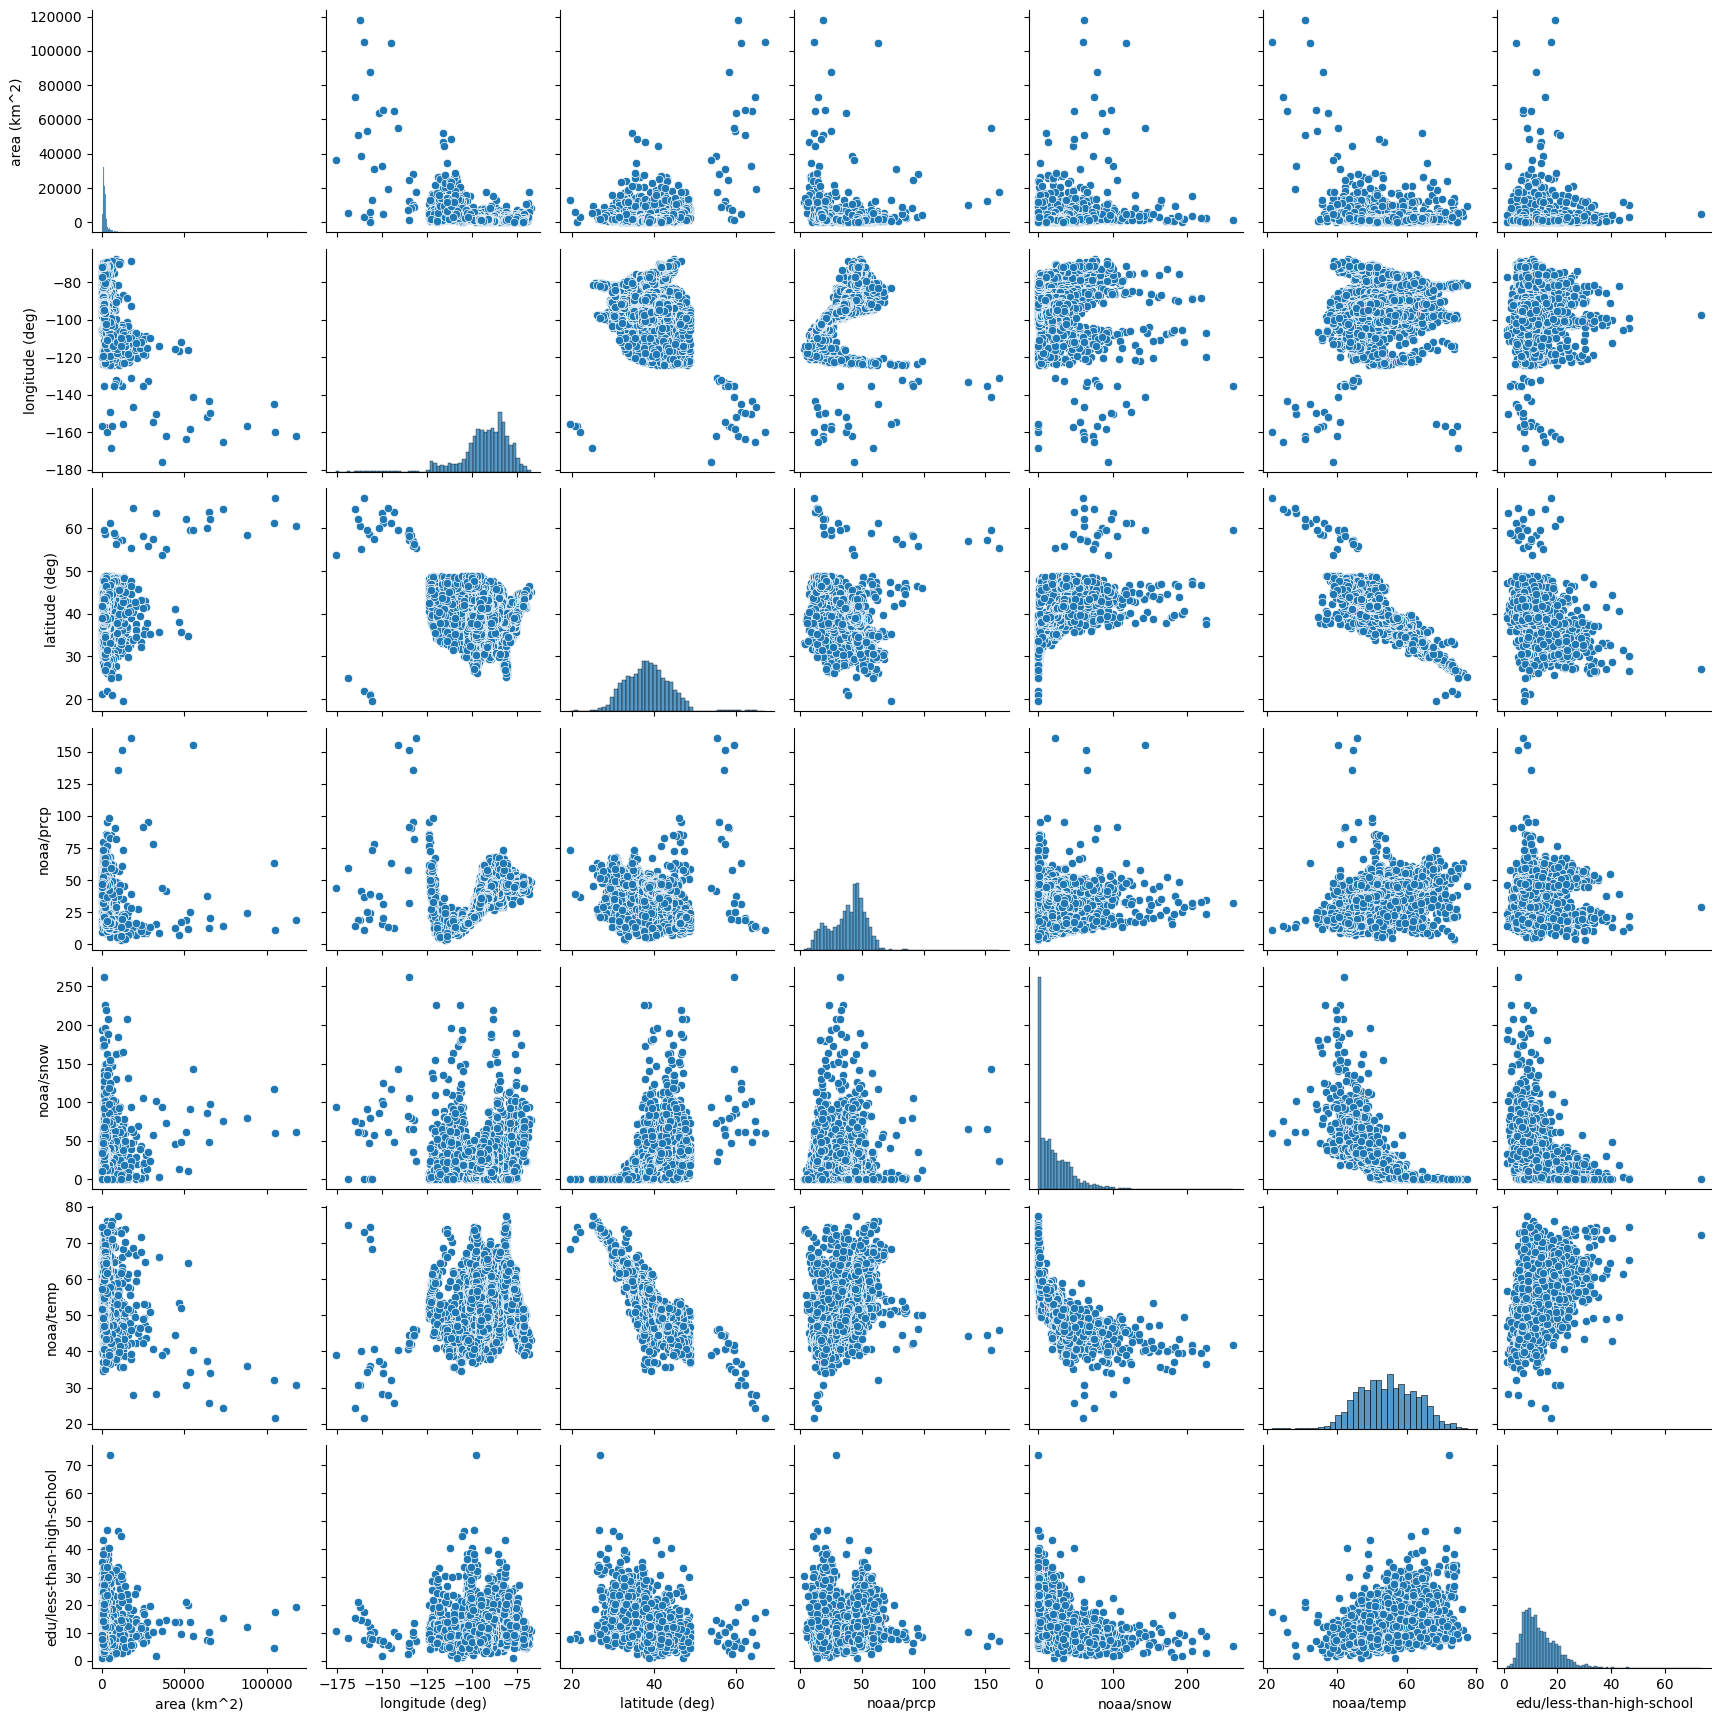

In [ ]:
sns.pairplot(counties)

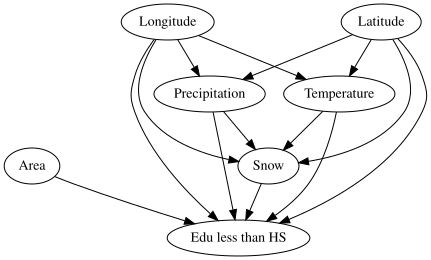

In [ ]:
countie = gv.Digraph(name="Counties")
countie.node('A','Area')
countie.node('B','Longitude')
countie.node('C','Latitude')
countie.node('D','Precipitation')
countie.node('E','Snow')
countie.node('F','Temperature')
countie.node('G','Edu less than HS')
countie.edges(['AG','BD','BE','BF','BG','CD','CE','CF','CG','DE','DG','EG','FE','FG'])
countie

Kind of hard to infer this but I assumed that extreme weather and area would be the main causes of Edu less than HS, as both factors make it difficult to get to school

In [ ]:
X = counties[[
             'area (km^2)',
             'longitude (deg)',
             'latitude (deg)',
             'noaa/prcp',
             'noaa/snow',
             'noaa/temp',
             ]]
Y = counties['edu/less-than-high-school']

Likelihood was right skewed and always positive so I chose gamma

In [ ]:
with pm.Model() as model_counties:
    s = pm.HalfNormal('s',10) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties,model_counties, extend_inferencedata=True)

(1.1, 73.6)

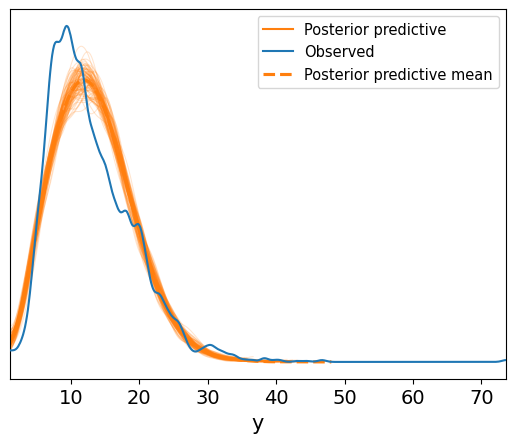

In [ ]:
ax = az.plot_ppc(idata_counties, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax.set_xlim(counties['edu/less-than-high-school'].min(), counties['edu/less-than-high-school'].max())

this looks good enough

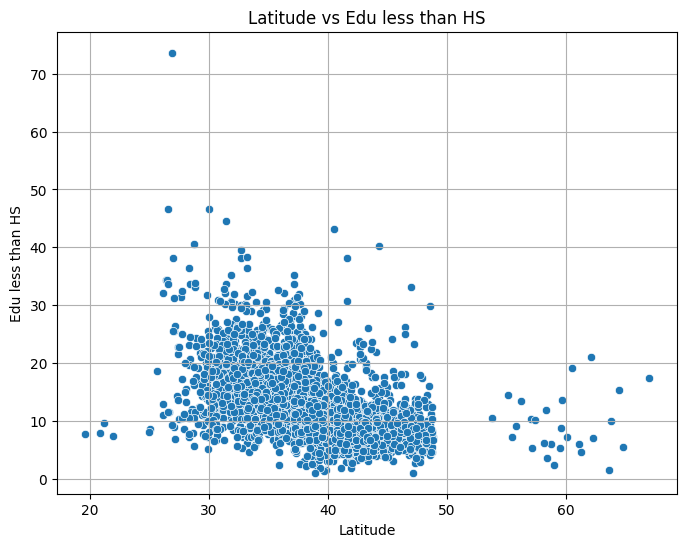

In [ ]:
plt.figure(figsize=(8, 6))#gemini
sns.scatterplot(x='latitude (deg)', y='edu/less-than-high-school', data=counties)
plt.title('Latitude vs Edu less than HS')
plt.xlabel('Latitude')
plt.ylabel('Edu less than HS')
plt.grid(True)
plt.show()

Gap in data makes me think this probably won't look great, alaska seems to be messing with things.

In [ ]:
posterior_mean = idata_counties.posterior["μ"]

μ_hdi = az.hdi(ary=idata_counties, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_counties, group="posterior_predictive", var_names=["y"]
    ).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


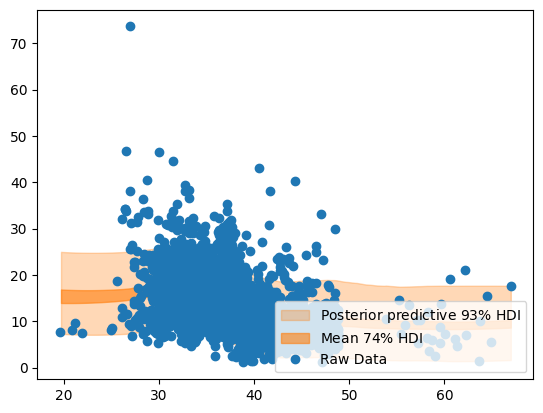

In [ ]:
idx = np.argsort(X.to_numpy()[:, 2])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 2],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 2],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(counties['latitude (deg)'], counties["edu/less-than-high-school"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="",
    xlabel="",
    ylabel="",
);

Not as bad as I thought it would be, but doesn't capture a lot of the points

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='area (km^2)'>, <Axes: xlabel='longitude (deg)'>,
       <Axes: xlabel='latitude (deg)'>, <Axes: xlabel='noaa/prcp'>,
       <Axes: xlabel='noaa/snow'>, <Axes: xlabel='noaa/temp'>],
      dtype=object)

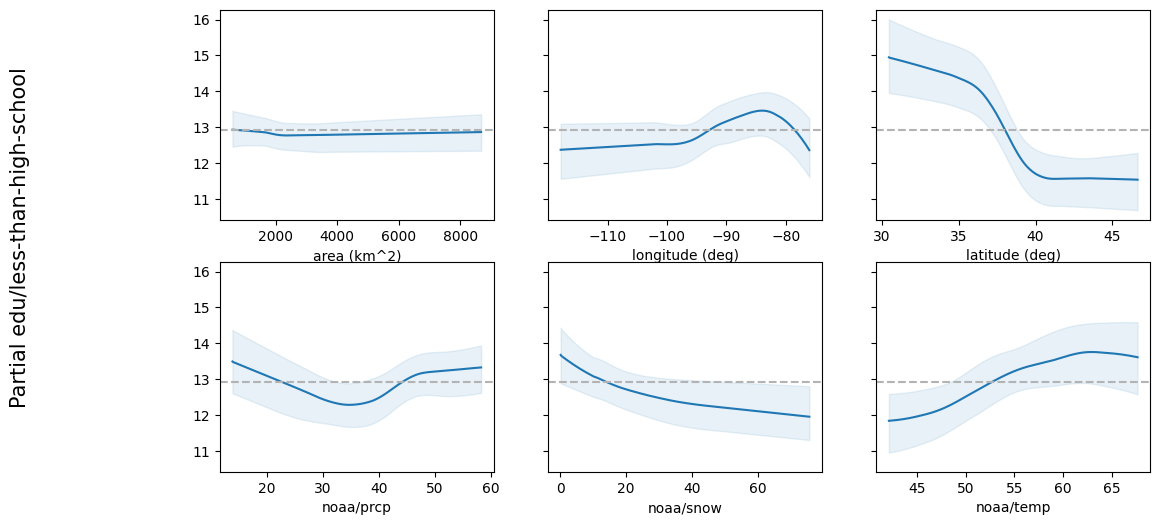

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 3), func=np.exp, figsize = (12,6))

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='area (km^2)'>, <Axes: xlabel='longitude (deg)'>,
       <Axes: xlabel='latitude (deg)'>, <Axes: xlabel='noaa/prcp'>,
       <Axes: xlabel='noaa/snow'>, <Axes: xlabel='noaa/temp'>],
      dtype=object)

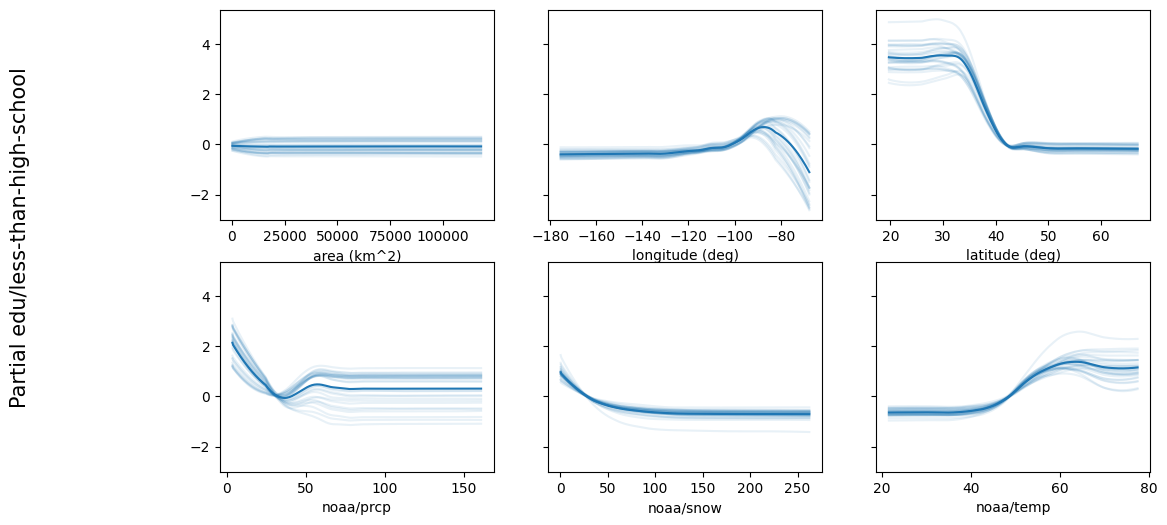

In [ ]:
pmb.plot_ice( μ_, X, Y, grid=(1, 3), func=np.exp, figsize = (12,6))

In [ ]:
vi_counties = pmb.compute_variable_importance(idata_counties, μ_, X, Y)

<Axes: ylabel='R²'>

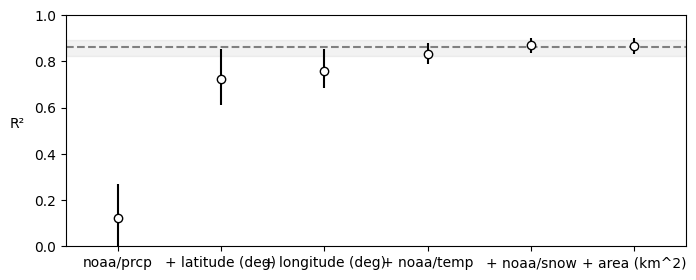

In [ ]:
pmb.plot_variable_importance(vi_counties)

This is interesting but now I am going to add the economic factors

In [ ]:
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv"
counties2 = pd.read_csv(url)
counties2 = counties2.query('`area (km^2)` < 200000')
print(list(counties2))

['name', 'fips', 'state', 'land_area (km^2)', 'area (km^2)', 'longitude (deg)', 'latitude (deg)', 'noaa/prcp', 'noaa/snow', 'noaa/temp', 'noaa/altitude', 'noaa/temp-jan', 'noaa/temp-apr', 'noaa/temp-jul', 'noaa/temp-oct', 'zip-codes', 'race/non_hispanic_white_alone_male', 'race/non_hispanic_white_alone_female', 'race/black_alone_male', 'race/black_alone_female', 'race/asian_alone_male', 'race/asian_alone_female', 'race/hispanic_male', 'race/hispanic_female', 'age/0-4', 'age/5-9', 'age/10-14', 'age/15-19', 'age/20-24', 'age/25-29', 'age/30-34', 'age/35-39', 'age/40-44', 'age/45-49', 'age/50-54', 'age/55-59', 'age/60-64', 'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+', 'male', 'female', 'population/2010', 'population/2011', 'population/2012', 'population/2013', 'population/2014', 'population/2015', 'population/2016', 'population/2017', 'population/2018', 'population/2019', 'deaths/suicides', 'deaths/firearm suicides', 'deaths/homicides', 'deaths/vehicle', 'bls/2004/labor_f

In [ ]:
counties2 = counties2.loc[:,["name","area (km^2)","longitude (deg)","latitude (deg)","noaa/prcp","noaa/snow","noaa/temp","edu/less-than-high-school","life-expectancy","avg_income","poverty-rate","cost-of-living/housing_costs"]]
counties2

,name,area (km^2),longitude (deg),latitude (deg),noaa/prcp,noaa/snow,noaa/temp,edu/less-than-high-school,life-expectancy,avg_income,poverty-rate,cost-of-living/housing_costs
0,cuming county,1488.343176,-96.787366,41.916346,30.5,28.2,48.8,11.6,81.20,58610,8.9,5460.0
1,lancaster county,2192.120047,-96.688211,40.784132,31.0,25.3,51.0,6.3,80.46,49889,10.7,7452.0
2,nuckolls county,1491.363670,-98.047277,40.176383,27.7,22.2,51.5,8.1,80.12,50836,11.2,5460.0
3,keith county,2874.204062,-101.657059,41.198294,20.0,25.0,50.0,8.5,79.24,45896,11.1,6312.0
4,phelps county,1399.695104,-99.414593,40.513105,25.5,26.7,50.3,6.7,79.86,52792,10.0,5460.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3137,washington county,1457.597303,-71.627758,41.385053,49.0,30.2,50.2,5.1,81.14,64158,8.0,9724.0
3138,providence county,1128.431056,-71.569018,41.870350,52.6,46.7,49.2,14.2,79.26,48137,14.0,9528.0
3139,bristol county,115.859939,-71.288552,41.704331,48.5,36.6,51.9,9.1,81.16,78805,6.8,9528.0
3140,newport county,812.295558,-71.286460,41.506366,47.4,36.6,51.6,6.0,81.15,68679,8.5,10632.0


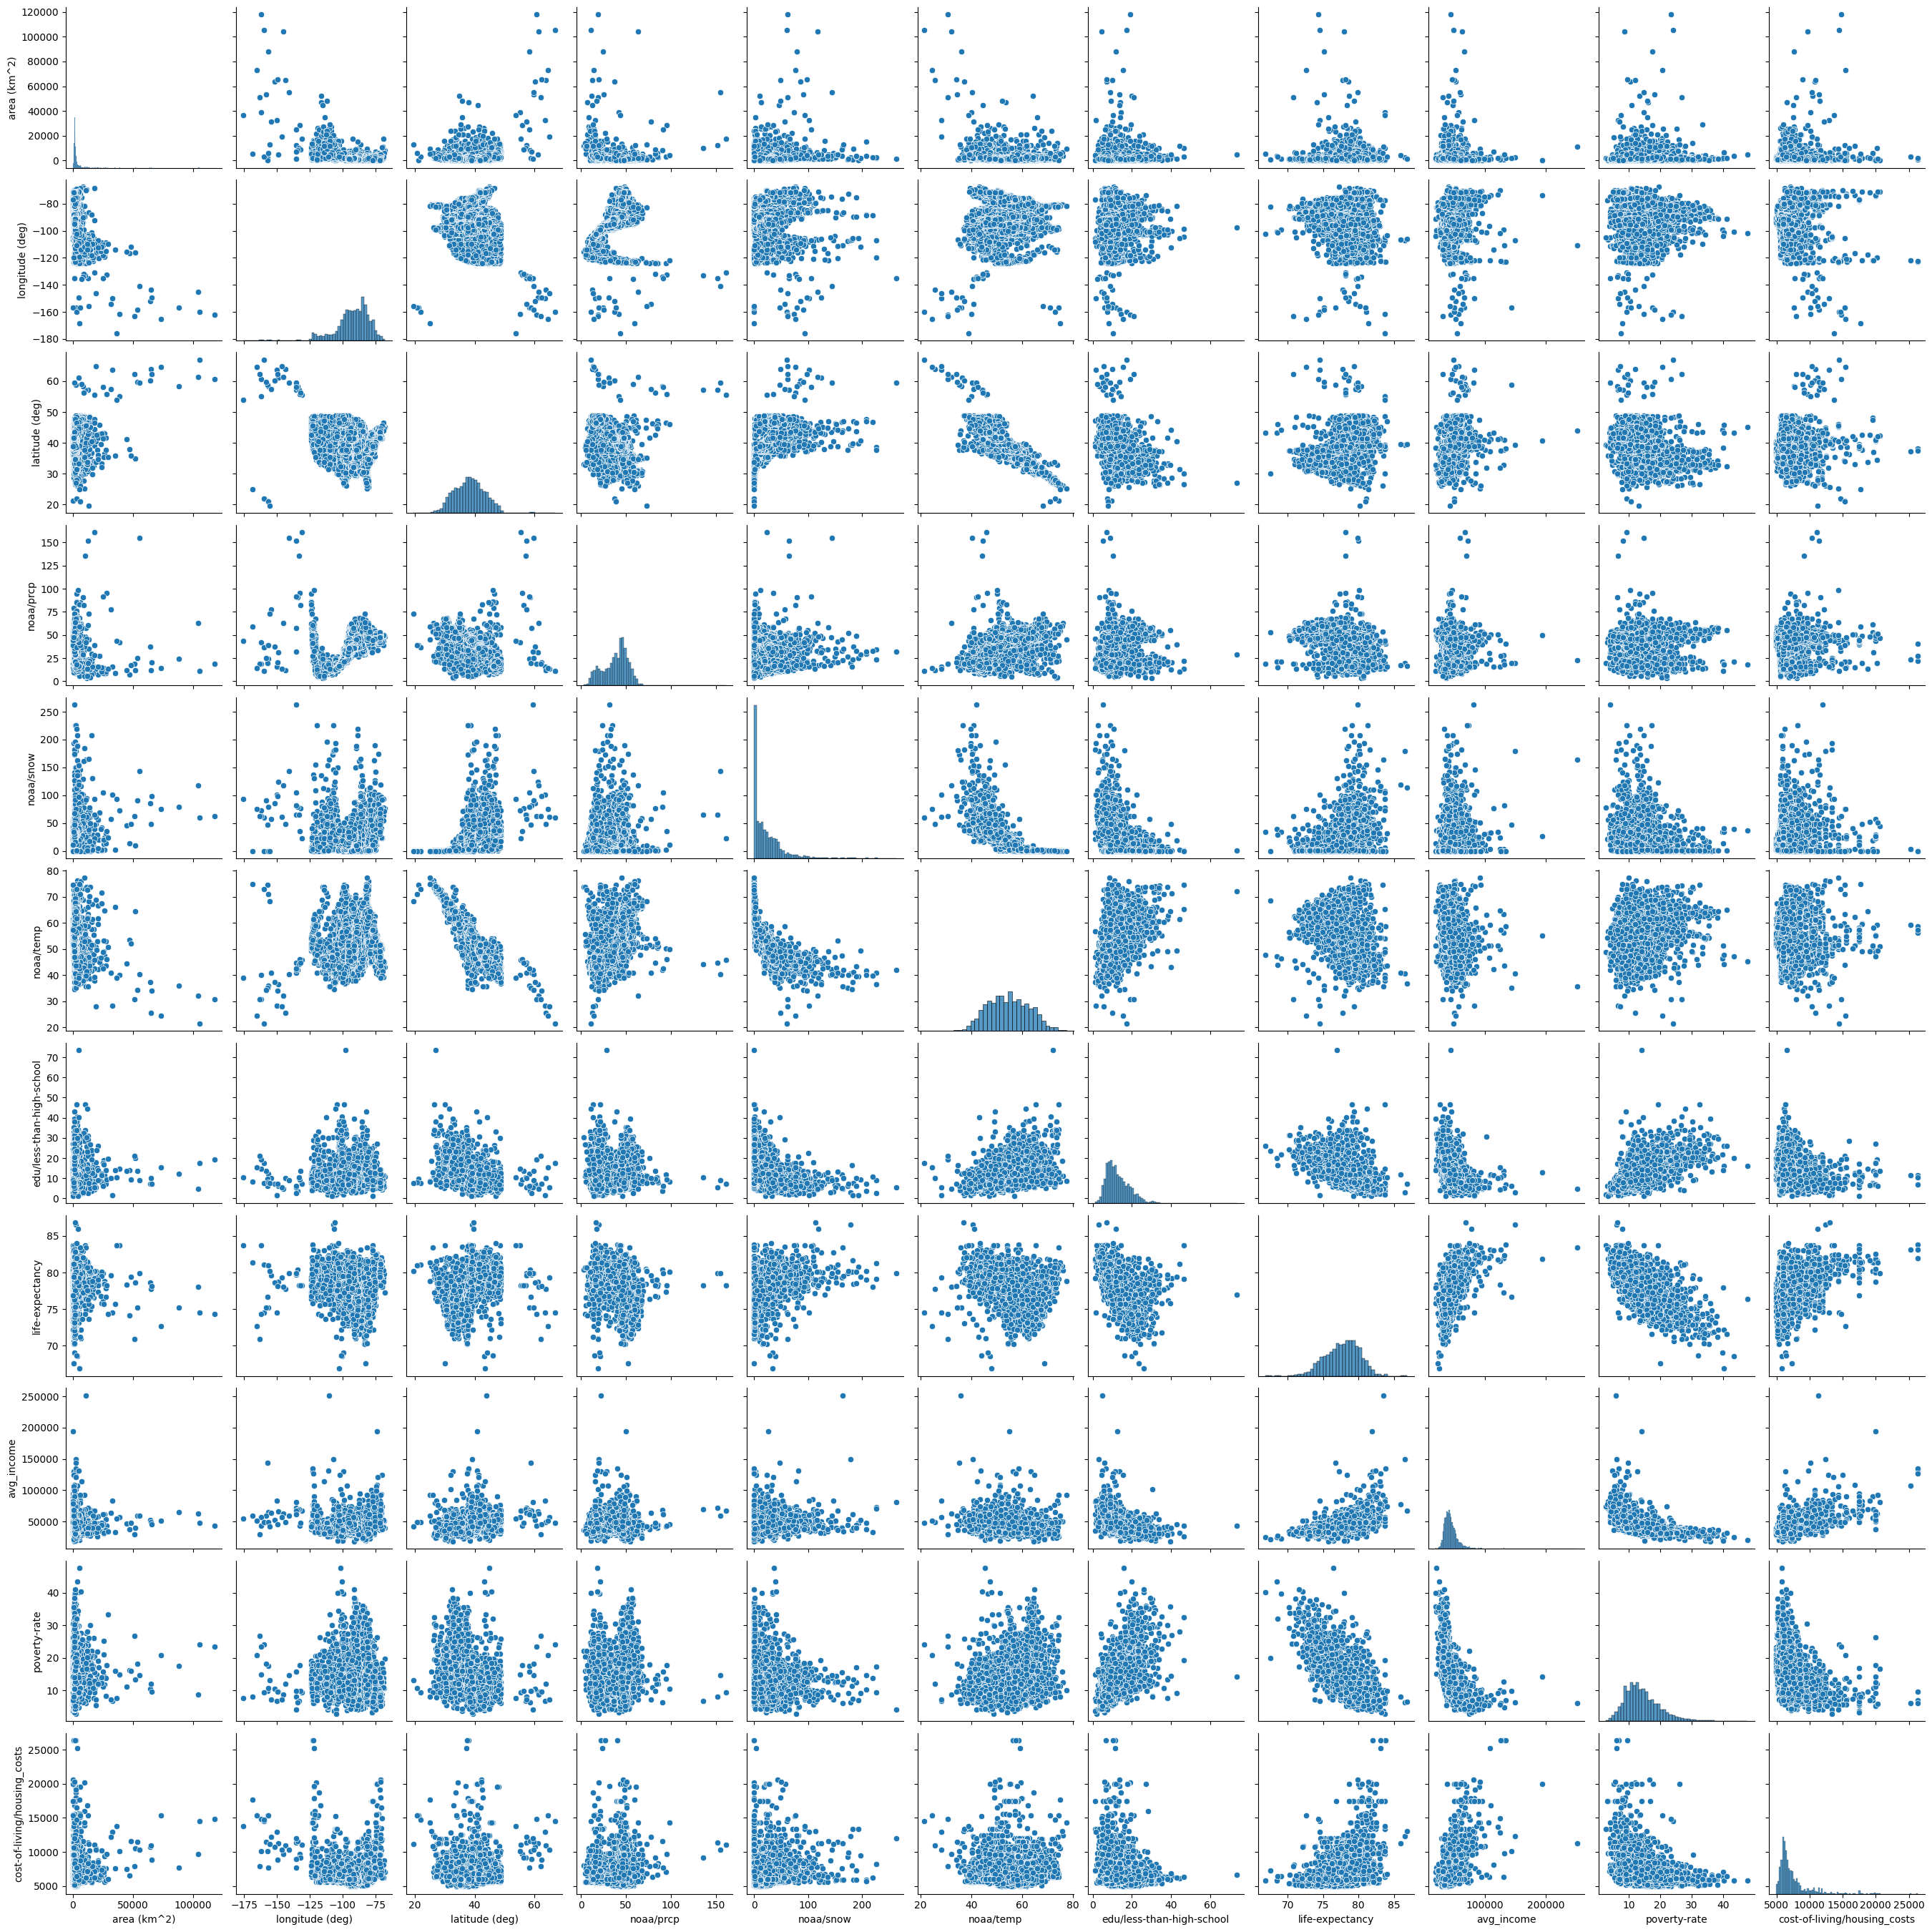

In [ ]:
sns.pairplot(counties2)

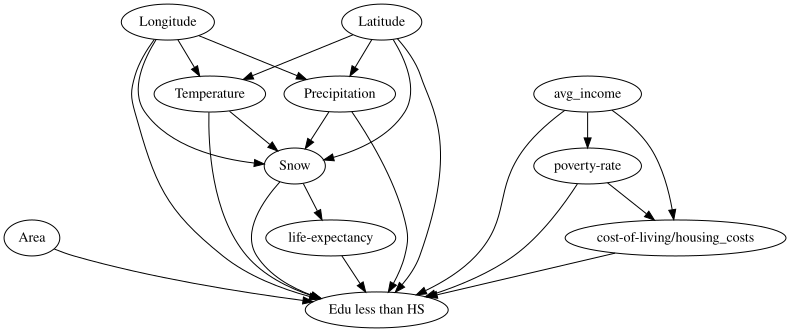

In [ ]:
countie2 = gv.Digraph(name="Counties2")
countie2.node('A','Area')
countie2.node('B','Longitude')
countie2.node('C','Latitude')
countie2.node('D','Precipitation')
countie2.node('E','Snow')
countie2.node('F','Temperature')
countie2.node('G','Edu less than HS')
countie2.node('H','life-expectancy')
countie2.node('I','avg_income')
countie2.node('J','poverty-rate')
countie2.node('K','cost-of-living/housing_costs')
countie2.edges(['AG','BD','BE','BF','BG','CD','CE','CF','CG','DE','DG','EG','FE','FG','HG','EH','IG','JG','IJ','KG','JK','IK'])
countie2

Looking back on this, I am not sure poverty rate causes cost of living and not the other way around but otherwise I think this is correct

In [ ]:
X2 = counties2[[
             'area (km^2)',
             'longitude (deg)',
             'latitude (deg)',
             'noaa/prcp',
             'noaa/snow',
             'noaa/temp',
             'life-expectancy',
             'avg_income',
             'poverty-rate',
             'cost-of-living/housing_costs'
             ]]
Y2 = counties2['edu/less-than-high-school']

In [ ]:
with pm.Model() as model_counties2:
    s2 = pm.HalfNormal('s2',10) #sigma = 20 is a blind guess
    μ_2 = pmb.BART("μ_2", X2, np.log(Y2), m=50) #log around Y
    μ2 = pm.Deterministic("μ2",pm.math.exp(μ_2)) #exp it all once BART is done
    y2 = pm.Gamma("y2", mu=μ2, sigma=s2,  observed=Y2) #likelihood
    idata_counties2 = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties2,model_counties2, extend_inferencedata=True)

(1.1, 73.6)

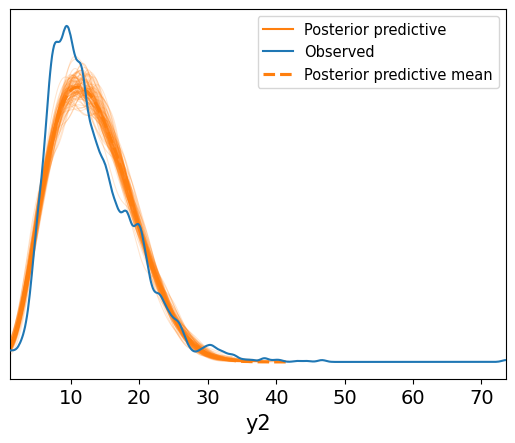

In [ ]:
ax2 = az.plot_ppc(idata_counties2, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax2.set_xlim(counties2['edu/less-than-high-school'].min(), counties2['edu/less-than-high-school'].max())

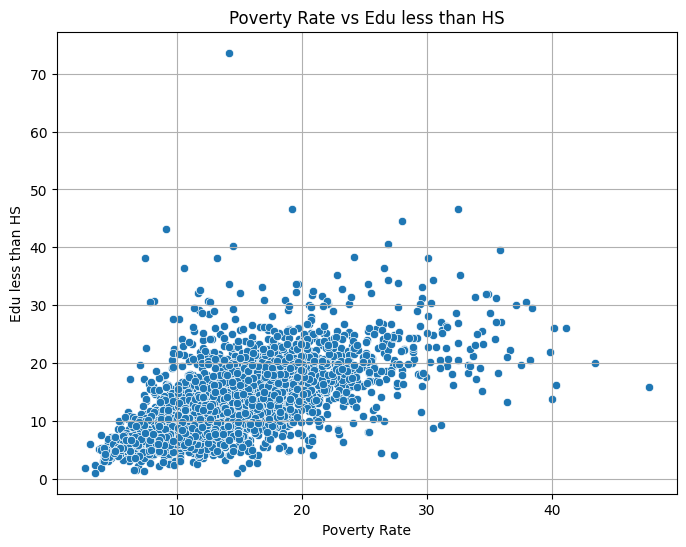

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='poverty-rate', y='edu/less-than-high-school', data=counties2)
plt.title('Poverty Rate vs Edu less than HS')
plt.xlabel('Poverty Rate')
plt.ylabel('Edu less than HS')
plt.grid(True)
plt.show()

In [ ]:
posterior_mean2 = idata_counties2.posterior["μ2"]

μ_2hdi = az.hdi(ary=idata_counties2, group="posterior", var_names=["μ2"], hdi_prob=0.74)

pps2 = az.extract(
    idata_counties2, group="posterior_predictive", var_names=["y2"]
    ).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


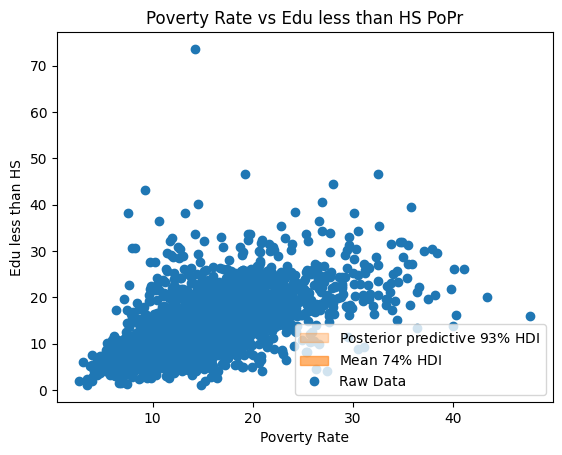

In [ ]:
idx = np.argsort(X2.to_numpy()[:, 8])
fig, ax2 = plt.subplots()

az.plot_hdi(
    x=X2.to_numpy()[:, 8],
    y=pps2,
    ax=ax2,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X2.to_numpy()[:, 8],
    y=posterior_mean2,
    ax=ax2,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax2.plot(counties2['poverty-rate'], counties2["edu/less-than-high-school"], "o", c="C0", label="Raw Data")
ax2.legend(loc="lower right")
ax2.set(
    title="Poverty Rate vs Edu less than HS PoPr",
    xlabel="Poverty Rate",
    ylabel="Edu less than HS",
);


I encountered a coding error where the posterior wouldn't be displayed, and I still couldn't get it to work after many attempts.

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:667: RuntimeWarning: All-NaN slice encountered
  x_data = np.linspace(np.nanmin(new_x), np.nanmax(new_x), 200)


array([<Axes: xlabel='area (km^2)'>, <Axes: xlabel='longitude (deg)'>,
       <Axes: xlabel='latitude (deg)'>, <Axes: xlabel='noaa/prcp'>,
       <Axes: xlabel='noaa/snow'>, <Axes: xlabel='noaa/temp'>,
       <Axes: xlabel='life-expectancy'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='cost-of-living/housing_costs'>], dtype=object)

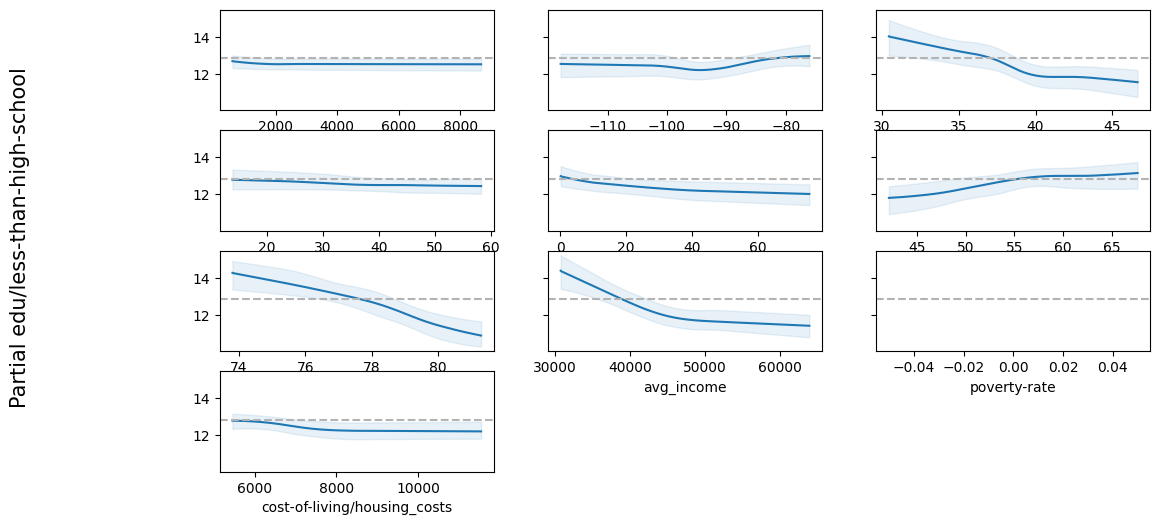

In [ ]:
pmb.plot_pdp(μ_2, X2, Y2, grid=(1, 3), func=np.exp, figsize = (12,6))

poverty rate line is outside the scope, it can be seen in the next graph

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='area (km^2)'>, <Axes: xlabel='longitude (deg)'>,
       <Axes: xlabel='latitude (deg)'>, <Axes: xlabel='noaa/prcp'>,
       <Axes: xlabel='noaa/snow'>, <Axes: xlabel='noaa/temp'>,
       <Axes: xlabel='life-expectancy'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='cost-of-living/housing_costs'>], dtype=object)

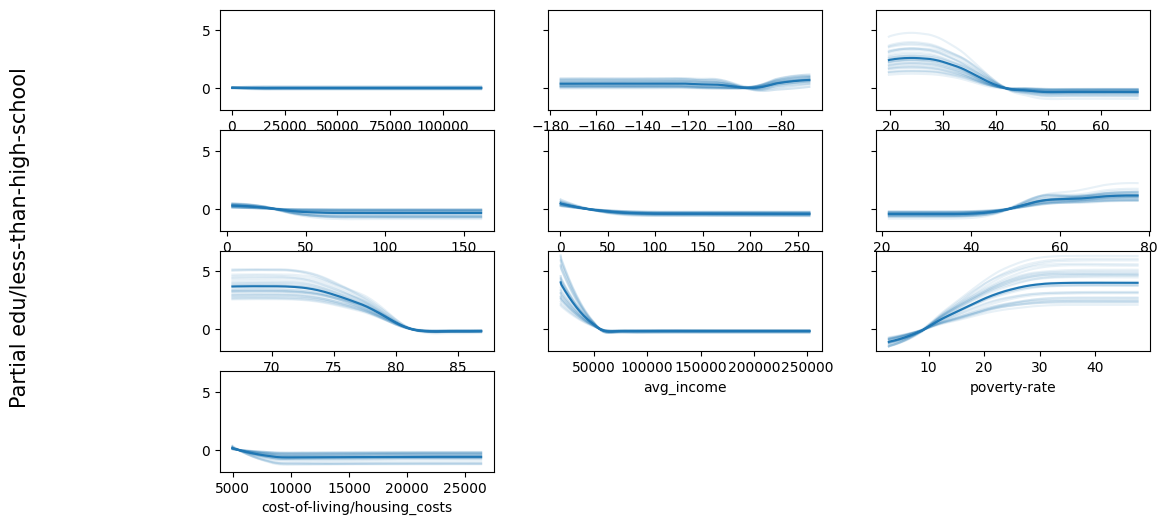

In [ ]:
pmb.plot_ice( μ_2, X2, Y2, grid=(1, 3), func=np.exp, figsize = (12,6))

In [ ]:
vi_counties2 = pmb.compute_variable_importance(idata_counties2, μ_2, X2, Y2)

<Axes: ylabel='R²'>

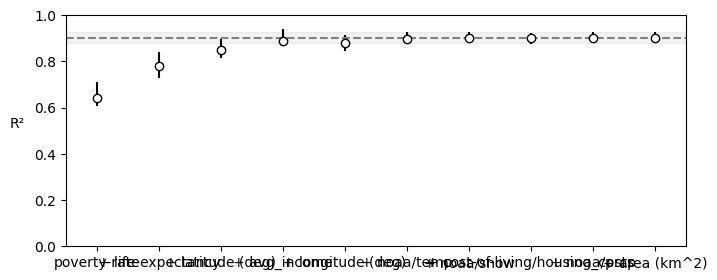

In [ ]:
pmb.plot_variable_importance(vi_counties2)

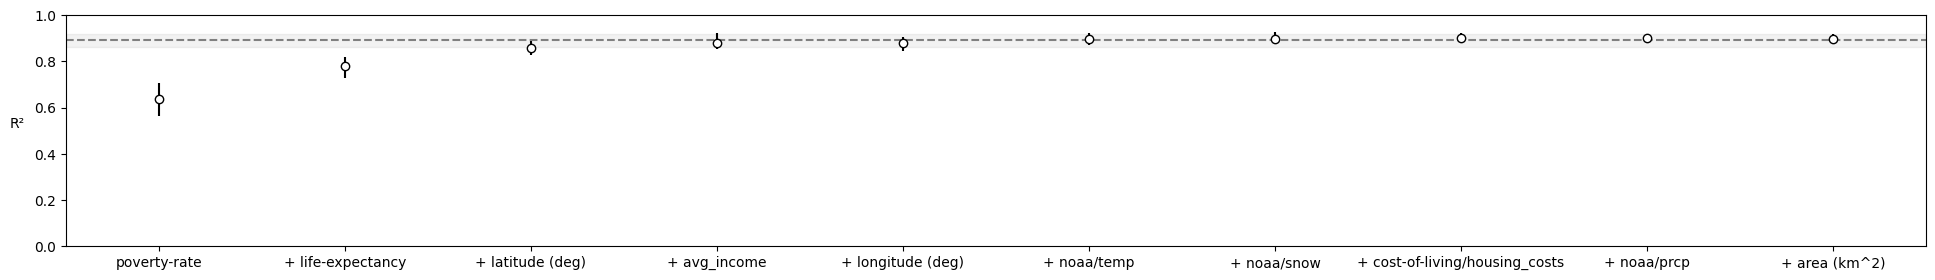

In [ ]:
fig, ax = plt.subplots(figsize=(24, 3)) #gemini
pmb.plot_variable_importance(vi_counties2, ax=ax)
plt.show()

We can see now that poverty rate and life-expectancy are much better indicators as they have a greater jump. I thought it was interesting that housing cost does not seem to matter very much.